In [44]:
!pip install timm
!pip install kaggle

In [45]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [46]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [47]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)


In [48]:
import zipfile

with zipfile.ZipFile("skin-cancer-mnist-ham10000.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [49]:
import os

os.listdir("dataset")

['hmnist_8_8_RGB.csv',
 'HAM10000_images_part_2',
 'HAM10000_metadata.csv',
 'ham10000_images_part_2',
 'hmnist_8_8_L.csv',
 'hmnist_28_28_L.csv',
 'HAM10000_images_part_1',
 'hmnist_28_28_RGB.csv',
 'ham10000_images_part_1']

In [50]:
!pip install timm

In [51]:
!pip install timm

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import timm

In [53]:
df = pd.read_csv("dataset/HAM10000_metadata.csv")

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [54]:
label_mapping = {
    'nv':0,
    'mel':1,
    'bkl':2,
    'bcc':3,
    'akiec':4,
    'vasc':5,
    'df':6
}

df['label'] = df['dx'].map(label_mapping)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


In [55]:
image_dir1 = "dataset/HAM10000_images_part_1"
image_dir2 = "dataset/HAM10000_images_part_2"

image_paths = []

for img_id in df['image_id']:

    path1 = os.path.join(image_dir1, img_id + ".jpg")
    path2 = os.path.join(image_dir2, img_id + ".jpg")

    if os.path.exists(path1):
        image_paths.append(path1)
    else:
        image_paths.append(path2)

df['path'] = image_paths

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2,dataset/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2,dataset/HAM10000_images_part_2/ISIC_0031633.jpg


In [56]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7010
Validation: 1502
Test: 1503


In [57]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [58]:
class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [59]:
train_dataset = SkinDataset(train_df, transform)
val_dataset = SkinDataset(val_df, transform)
test_dataset = SkinDataset(test_df, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    'seresnet50',
    pretrained=True,
    num_classes=7
)

model = model.to(device)

print("SENet Model Loaded Successfully")

SENet Model Loaded Successfully


In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [62]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 10

In [63]:
for epoch in range(epochs):

    # TRAINING MODE
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    # VALIDATION MODE
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}]")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_accuracy:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

    print(f"Validation Accuracy: {val_accuracy:.4f}")

    print("-----------------------------------")

Epoch [1/10]
Train Loss: 0.7864
Train Accuracy: 0.7250
Validation Loss: 0.6469
Validation Accuracy: 0.7523
-----------------------------------
Epoch [2/10]
Train Loss: 0.5565
Train Accuracy: 0.8049
Validation Loss: 0.6679
Validation Accuracy: 0.7324
-----------------------------------
Epoch [3/10]
Train Loss: 0.4244
Train Accuracy: 0.8431
Validation Loss: 0.5261
Validation Accuracy: 0.8009
-----------------------------------
Epoch [4/10]
Train Loss: 0.3132
Train Accuracy: 0.8850
Validation Loss: 0.6176
Validation Accuracy: 0.7963
-----------------------------------
Epoch [5/10]
Train Loss: 0.2543
Train Accuracy: 0.9074
Validation Loss: 0.6548
Validation Accuracy: 0.8076
-----------------------------------
Epoch [6/10]
Train Loss: 0.1582
Train Accuracy: 0.9434
Validation Loss: 0.7052
Validation Accuracy: 0.8089
-----------------------------------
Epoch [7/10]
Train Loss: 0.1332
Train Accuracy: 0.9556
Validation Loss: 0.5275
Validation Accuracy: 0.8196
-----------------------------------

In [64]:
torch.save(model.state_dict(), "senet_skin_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [65]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())

        all_preds.extend(predicted.cpu().numpy())

In [66]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.8396540252827678
Precision: 0.8369933250692144
Recall   : 0.8396540252827678
F1 Score : 0.8314275553121476


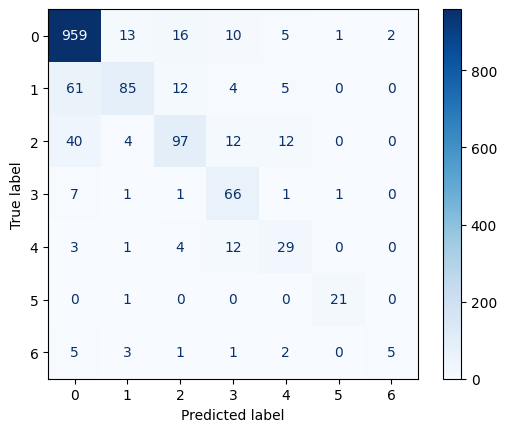

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.show()

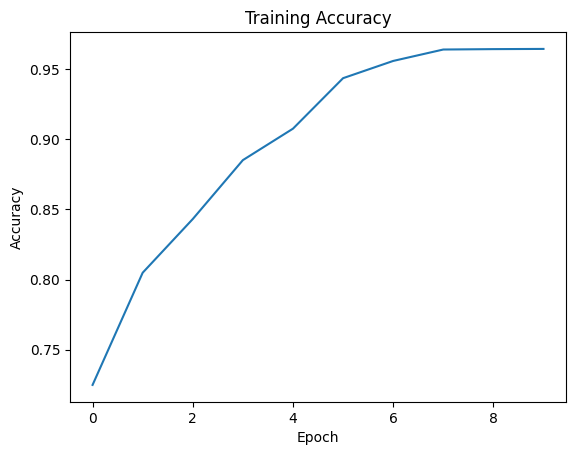

In [68]:
plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

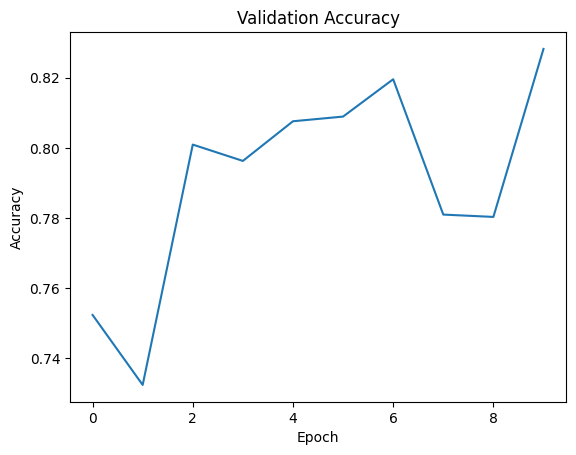

In [69]:
plt.plot(val_accuracies)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

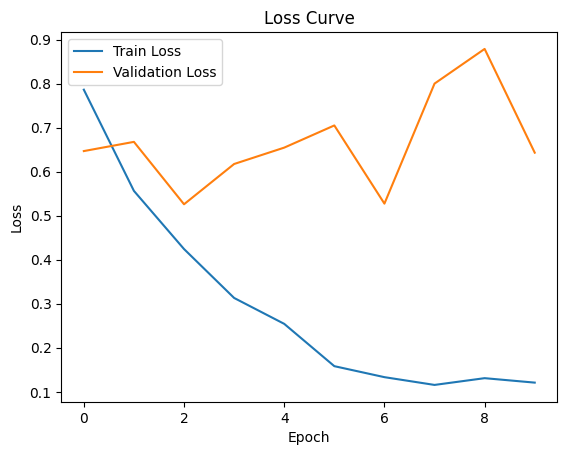

In [70]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.show()